Sheet 3.1: Transformer (2) - Beyond attention
===
**Author**: Amir Mohammadpour

Attention, as you have implemented it, is a set operation. The output at any position is a weighted sum over a set of value vectors, and the weights are determined by compatibility between queries and keys. Nothing in this computation references order. You could permute the input sequence arbitrarily and the mechanism would produce the same outputs, just reordered to match. For a model that is supposed to process language — where *the dog bit the man* and *the man bit the dog* are not the same sentence — this is a genuine problem. The fix is conceptually simple and technically interesting: position must be injected into the representation explicitly, before attention operates, and how you do it is a design choice with consequences.

Beyond positional encoding, a complete transformer block contains several further components: a feedforward layer applied independently at each position after attention has mixed information across the sequence, and layer normalisation to keep representations well-behaved as the network deepens. These components do not operate in isolation — each one reads from and writes to a shared residual stream, a view of the computation that will prove useful when reasoning about what different parts of the network are doing and where. At the boundaries of the model sit an embedding matrix that maps discrete token indices into vectors, and an unembedding matrix that projects those vectors back to logits over the vocabulary. This notebook builds each of these components in turn and assembles them into a complete language model.


---
## 1 . Positional Embeddings

Having mentioned that the attention mechanism is permutation invariance, we now seek to elaborate on the solution. The standard way to tackle this is to add a positional signal to the token representations before any attention is computed, so that the model receives, at each position, both the identity of the token and its location in the sequence. The question is what form that signal should take.

The original transformer paper introduced a deterministic signal constructed from sinusoids of varying frequency. For a sequence position $t$
and embedding dimension $i$ the positional encoding is defined as: $$PE_{(t, 2i)} = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad PE_{(t, 2i+1)} = \cos\!\left(\frac{t}{10000^{2i/d}}\right)$$

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, d_model: int, max_seq_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_seq_len, d_model)
        positions = torch.arange(max_seq_len).unsqueeze(1)          # (T, 1)
        dims = torch.arange(0, d_model, 2)                          # even indices
        freqs = torch.pow(10000.0, -dims / d_model)                 # (d_model/2,)

        pe[:, 0::2] = torch.sin(positions * freqs)
        pe[:, 1::2] = torch.cos(positions * freqs)

        self.register_buffer("pe", pe.unsqueeze(0))                 # (1, T, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]

It is worth visualising the encoding matrix before proceeding. Even dimensions receive a sine, odd dimensions a cosine. Along the dimension axis — moving across the columns of the encoding matrix — the base frequency decreases with $i$ so each dimension oscillates at its own fixed rate as a function of position. Along the position axis — moving down the rows — low-indexed dimensions complete many cycles across the sequence while high-indexed dimensions vary almost imperceptibly. The encoding assigned to each position is therefore a superposition of sinusoids at different frequencies, and because no two positions share the same superposition, the representation is unique per position. The visualisation below makes both axes readable at once.

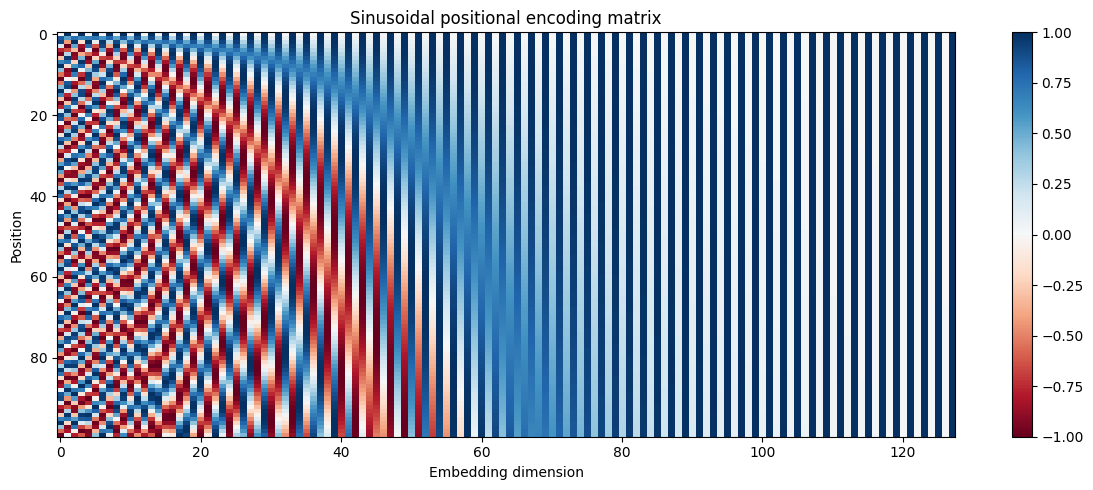

In [4]:
pe_module = SinusoidalPositionalEmbedding(d_model=128, max_seq_len=100)
pe_matrix = pe_module.pe.squeeze(0).numpy()                        # (100, 128)

plt.figure(figsize=(12, 5))
plt.imshow(pe_matrix, aspect="auto", cmap="RdBu")
plt.colorbar()
plt.xlabel("Embedding dimension")
plt.ylabel("Position")
plt.title("Sinusoidal positional encoding matrix")
plt.tight_layout()
plt.show()

The sinusoidal encoding was the default choice for several years and remains in wide use. Its main limitation is that it is fixed by construction: the model cannot learn to adjust the positional representation to suit the data. A natural alternative is to treat position as a learnable quantity in the same way tokens are — replacing the deterministic formula with an embedding table indexed by position.

In [6]:
class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, d_model: int, max_seq_len: int = 512):
        super().__init__()
        self.embedding = nn.Embedding(max_seq_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        T = x.size(1)
        positions = torch.arange(T, device=x.device)
        return x + self.embedding(positions)

Learned embeddings tend to perform comparably to sinusoidal encodings on standard benchmarks, at the cost of a fixed maximum sequence length set at initialisation. Which choice is appropriate depends on the application; for this notebook, either will serve.

---
## 2. Feedforward Layers

Each transformer block applies a two-layer MLP to every token vector independently — pointwise in the sense that no information crosses between positions at this stage. The transformation is:

$$\text{FFN}(x) = W_2 \, \sigma(W_1 x + b_1) + b_2$$

The nonlinearity $\sigma$ is what makes this non-trivial. Without it, $W_2 W_1$ is just a single linear map and the two layers are redundant. With it, the network can approximate functions that no linear projection can represent. GPT-2 uses GELU; the original transformer used ReLU. The difference is minor in practice, but GELU's smooth gradient near zero has made it the default in most subsequent work.

The inner dimension $d_{\text{ff}}$ is set to $4d$ in the standard architecture — a ratio that is largely empirical but has proven robust across scales. The expansion gives the nonlinearity room to operate in a higher-dimensional space before the second projection collapses the representation back to $d$.

> **Exercise:** Implement the `forward` pass — project through `w1`, apply a nonlinearity, then project through `w2`. Try swapping `gelu` for `relu` and inspect the output values. Try to do it yourself and pass the unit test first.

In [7]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError

<details>
<summary>Solution</summary>

```python
def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.w2(F.gelu(self.w1(x)))
```

</details>

In [ ]:
# --- tests ---
def test_feedforward():
    torch.manual_seed(0)
    d_model, batch, seq_len = 32, 2, 10
    ff = FeedForward(d_model=d_model)

    x = torch.randn(batch, seq_len, d_model)
    out = ff(x)

    assert out.shape == x.shape, \
        f"Expected output shape {x.shape}, got {out.shape}"
    assert not torch.allclose(out, x), \
        "Output is identical to input — is the forward pass doing anything?"
    assert out.requires_grad == False, \
        "Output should not require grad in inference mode"

    print("All tests passed.")

test_feedforward()

---
## 3. Layer Normalisation

As a network deepens, the distribution of activations at each layer shifts during training — a consequence of parameter updates propagating through the computation. Normalisation layers counteract this by standardising activations before they are passed forward, stabilising the training dynamics.

The name is somewhat misleading on both counts. The operation is standardisation, not normalisation — it subtracts the mean and divides by the standard deviation, producing a zero-mean unit-variance distribution, rather than rescaling values to a fixed range. And it does not operate on a layer: it operates on individual token vectors. Given a token's feature vector $x \in \mathbb{R}^d$, it computes the mean and variance across the $d$ features of that token alone:

$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}, \qquad \mu = \frac{1}{d}\sum_{i=1}^d x_i, \qquad \sigma^2 = \frac{1}{d}\sum_{i=1}^d (x_i - \mu)^2$$

The result is then rescaled by learned parameters $\gamma$ and $\beta$ — one per feature dimension — which allow the model to recover any distribution it finds useful after standardisation:

$$\text{LayerNorm}(x) = \gamma \odot \hat{x} + \beta$$

No information is shared across the sequence or across the batch: each token is standardised against its own feature statistics. This is what distinguishes layer normalisation from batch normalisation, which standardises across the batch dimension and is therefore sensitive to batch size and inapplicable at inference time with a single sample.

LayerNorm does not change the shape of the distribution — it is a shift and a rescaling, so the histogram looks the same before and after. What changes is the location, pulled to zero mean, and the spread, compressed to unit variance. The plot below makes both visible.

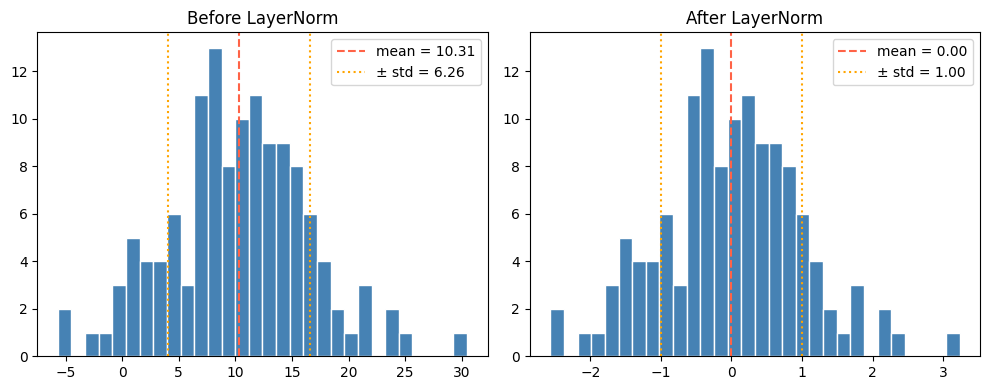

In [16]:
torch.manual_seed(0)
d_model = 128

x = torch.randn(d_model) * 6 + 10 # manually scale and shift to create a non-standard distribution

mean = x.mean()
var  = x.var(unbiased=False)
x_hat = (x - mean) / torch.sqrt(var + 1e-5)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
for ax, values, title in zip(axes, [x, x_hat], ["Before LayerNorm", "After LayerNorm"]):
    ax.hist(values.detach().numpy(), bins=30, color="steelblue", edgecolor="white")
    ax.axvline(values.mean().item(), color="tomato", linestyle="--",
               label=f"mean = {values.mean():.2f}")
    ax.axvline(values.mean().item() + values.std().item(), color="orange",
               linestyle=":", label=f"± std = {values.std():.2f}")
    ax.axvline(values.mean().item() - values.std().item(), color="orange", linestyle=":")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

> **Exercise:** Implement `LayerNorm` from scratch. Compute the mean and variance across the feature dimension of each token, standardise, then apply the learned scale $\gamma$ and shift $\beta$.

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
        self.eps   = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        raise NotImplementedError

<details>
<summary>Solution</summary>

```python
def forward(self, x: torch.Tensor) -> torch.Tensor:
    mean = x.mean(dim=-1, keepdim=True)
    var  = x.var(dim=-1, keepdim=True, unbiased=False)
    x_hat = (x - mean) / torch.sqrt(var + self.eps)
    return self.gamma * x_hat + self.beta
```

</details>

In [ ]:
# --- tests ---
def test_layernorm():
    torch.manual_seed(0)
    batch, seq_len, d_model = 2, 10, 64
    x = torch.randn(batch, seq_len, d_model) * 5 + 3

    custom_ln = LayerNorm(d_model)
    ref_ln    = nn.LayerNorm(d_model)

    # sync parameters
    ref_ln.weight.data = custom_ln.gamma.data.clone()
    ref_ln.bias.data   = custom_ln.beta.data.clone()

    out_custom = custom_ln(x)
    out_ref    = ref_ln(x)

    assert out_custom.shape == x.shape, \
        f"Expected shape {x.shape}, got {out_custom.shape}"
    assert torch.allclose(out_custom, out_ref, atol=1e-5), \
        "Output does not match nn.LayerNorm — check mean/variance computation"
    assert torch.allclose(out_custom.mean(dim=-1), torch.zeros(batch, seq_len), atol=1e-5), \
        "Token means are not zero after normalisation"
    assert torch.allclose(out_custom.var(dim=-1, unbiased=False), torch.ones(batch, seq_len), atol=1e-5), \
        "Token variances are not one after normalisation — check epsilon handling"

    print("All tests passed.")

test_layernorm()

---
## 4. Embedding and Unembedding

The model operates entirely in $\mathbb{R}^d$, but its inputs are discrete — token indices drawn from a vocabulary of size $V$. The embedding matrix $W_E \in \mathbb{R}^{V \times d}$ bridges this gap: each token index is mapped to the corresponding row of $W_E$, producing a dense vector that the rest of the model can operate on. This is a lookup, not a linear transformation, and it is learned end-to-end.

At the other end of the model, the unembedding matrix $W_U \in \mathbb{R}^{d \times V}$ projects the final hidden state back to a vector of logits over the vocabulary. A softmax over these logits gives a probability distribution from which the next token can be sampled or evaluated.

The two matrices are often tied — that is, $W_U = W_E^\top$ — so that the same parameters serve both roles. The justification is that the embedding matrix has already learned a geometry over the vocabulary: tokens that are semantically similar occupy nearby regions of $\mathbb{R}^d$. The unembedding is performing the inverse operation, projecting back into that same space, so sharing the parameters is not only a regularisation convenience but geometrically coherent. Weight tying also reduces the parameter count by $V \times d$, which is non-trivial for large vocabularies.

In [17]:
class Embedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(vocab_size, d_model) * 0.02)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        # idx: (batch, seq_len) of integer token indices
        return self.weight[idx]


class Unembedding(nn.Module):
    def __init__(self, embedding: Embedding, tied: bool = True):
        super().__init__()
        self.tied = tied
        if tied:
            self.weight = embedding.weight        # shared reference, no extra parameters
        else:
            self.weight = nn.Parameter(embedding.weight.data.clone())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model) -> logits: (batch, seq_len, vocab_size)
        return x @ self.weight.T

---
## 5. Residual Connections

Each component so far — attention, the feedforward layer, layer normalisation — operates on a vector and produces a vector of the same dimension. Residual connections wire these components together by adding each component's output back to its input rather than passing it through directly:

$$x \leftarrow x + \text{Sublayer}(x)$$

The practical consequence is that gradients can flow backward through the addition operation without passing through the sublayer, which becomes important as the network deepens. The deeper consequence is that each sublayer is learning a correction to the current representation rather than a wholesale transformation of it — the residual stream accumulates contributions from attention and the feedforward layers as the input passes through successive blocks.

This framing makes the assembly natural: attention reads from the stream and writes a correction back, the feedforward layer does the same, and layer normalisation is applied before each sublayer to keep the stream well-behaved as it deepens. With that in place, a full transformer block is just these operations composed in order.

The cell below reproduces the `MultiHeadAttention` module from the previous notebook. It is included here so this notebook runs self-contained.

In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        B, T, C = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_head)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        out  = (attn @ V).transpose(1, 2).contiguous().view(B, T, C)
        return self.W_o(out)

In [19]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int = None):
        super().__init__()
        self.ln1  = LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)   # from previous notebook
        self.ln2  = LayerNorm(d_model)
        self.ff   = FeedForward(d_model, d_ff)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        # pre-norm: normalise before each sublayer, add residual after
        x = x + self.attn(self.ln1(x), mask=mask)
        x = x + self.ff(self.ln2(x))
        return x

With all components in place, we run a single forward and backward pass through one transformer block. The loss here is not meaningful — `out.mean()` is a convenience scalar, not a training objective. What matters is that the output shape is correct and that gradients reach every component.

In [ ]:
torch.manual_seed(0)

d_model  = 64
n_heads  = 4
batch    = 2
seq_len  = 16

block = TransformerBlock(d_model=d_model, n_heads=n_heads)
x     = torch.randn(batch, seq_len, d_model)

# forward
out  = block(x)
print("Output shape:", out.shape)          # (2, 16, 64)

# backward
loss = out.mean()
loss.backward()
print("W_q grad norm:", block.attn.W_q.weight.grad.norm().item())

> **Think about it**: The block above applies layer normalisation *before* each sublayer — a convention known as pre-norm, adopted by GPT-2 and most subsequent work. The original transformer applied it *after*, which changes both the training dynamics and the gradient flow through the residual stream. As you move to the next session, consider: what does the residual stream look like at initialisation under each convention, and which do you expect to be easier to train deep?